# 05 · Eventos

**Preguntas:**
- ¿Cuántos eventos hay, de qué tipo, cuánto duran y cuántos sensores los ven?
- ¿Cuántos eventos ocurren en la red sin que ningún sensor los note?
- ¿Cómo se ve cada tipo de evento en las lecturas, y qué lo distingue de la operación normal y de
  una falla del sensor?
- ¿Qué tan desbalanceados están los datos para entrenar un detector?

Hay tres niveles de etiqueta:

| Columna | Qué indica |
|---|---|
| `evento_red` | hay un evento ocurriendo en algún lugar de la red, aunque ningún sensor lo vea |
| `evento_<nodo>` | el evento es **visible** en ese sensor (cambia sus lecturas de forma medible) |
| `evento_visible` | el evento es visible en al menos un sensor |

Tipos: **contaminación** (entrada de un contaminante en un punto de la red), **falla de
cloración**, **turbidez en la fuente** y **falla de pH**. Los tres últimos empiezan en la fuente.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src import carga, calidad
from src.eventos import episodios
from src.graficos import estilo, guardar, COLORES, GRIS

estilo()
pd.set_option("display.precision", 2)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

crudo = carga.cargar_todo()
t = calidad.lecturas_validas(crudo)
S = carga.sensores(t)
TIPOS = ["contaminacion", "falla_cloro", "turbidez_fuente", "falla_ph"]
NOMBRE = {"contaminacion": "Contaminación", "falla_cloro": "Falla de cloración",
          "turbidez_fuente": "Turbidez en la fuente", "falla_ph": "Falla de pH", "normal": "Normal"}
COLOR = {"normal": GRIS, "contaminacion": COLORES[7], "falla_cloro": COLORES[1],
         "turbidez_fuente": COLORES[3], "falla_ph": COLORES[6]}
E = t[[f"evento_{n}" for n in S]]
E.columns = S

## 1. Cuántos eventos hay y cómo se ven en la red

Cada **episodio** es un tramo continuo de `evento_red` con el mismo tipo. Para cada uno se cuenta
cuántos sensores llegan a verlo (durante el episodio o hasta 24 h después, por el tiempo de viaje
del agua) y cuánto tarda el primero en verlo.

In [2]:
red = episodios(t["evento_red"])
filas = []
for _, ep in red.iterrows():
    ventana = E.loc[ep.inicio: ep.fin + pd.Timedelta(hours=24)]
    ven = ventana.columns[(ventana == ep.codigo).any()]
    if len(ven):
        primero = ventana.index[(ventana[ven] == ep.codigo).any(axis=1)][0]
        retraso = (primero - ep.inicio).total_seconds() / 3600
    else:
        retraso = np.nan
    filas.append({"sensores que lo ven": len(ven), "horas hasta verse": retraso})
red = pd.concat([red, pd.DataFrame(filas)], axis=1)
red["visible"] = red["sensores que lo ven"] > 0

resumen = red.groupby("tipo").agg(
    episodios=("tipo", "size"),
    duración_mediana_h=("horas", "median"),
    duración_máx_h=("horas", "max"),
    pct_visibles=("visible", lambda x: 100 * x.mean()),
    sensores_que_lo_ven_mediana=("sensores que lo ven", lambda x: x[x > 0].median()),
    horas_hasta_verse_mediana=("horas hasta verse", "median"),
).loc[TIPOS].rename(index=NOMBRE)
resumen

,episodios,duración_mediana_h,duración_máx_h,pct_visibles,sensores_que_lo_ven_mediana,horas_hasta_verse_mediana
tipo,,,,,,
Contaminación,100,20.00,121.75,74.00,1.0,1.0
Falla de cloración,41,24.00,88.00,58.54,21.0,0.0
Turbidez en la fuente,11,71.75,163.75,72.73,21.0,0.0
Falla de pH,36,42.38,174.00,75.00,21.0,0.0


In [3]:
red["partición"] = pd.cut(red["inicio"], [pd.Timestamp("2000-01-01"), pd.Timestamp("2026-05-01"),
                                          pd.Timestamp("2026-09-01"), pd.Timestamp("2100-01-01")],
                          labels=carga.PARTICIONES, right=False)
red.pivot_table(index="tipo", columns="partición", values="visible", aggfunc="sum", observed=False) \
   .loc[TIPOS].rename(index=NOMBRE).astype(int).rename_axis(None, axis=1) \
   .assign(total=lambda d: d.sum(axis=1))

,entrenamiento,validacion,prueba,total
tipo,,,,
Contaminación,50,11,13,74
Falla de cloración,10,9,5,24
Turbidez en la fuente,5,0,3,8
Falla de pH,21,1,5,27


Los números de la tabla anterior son episodios **visibles** por partición: los que un modelo
podría llegar a detectar.

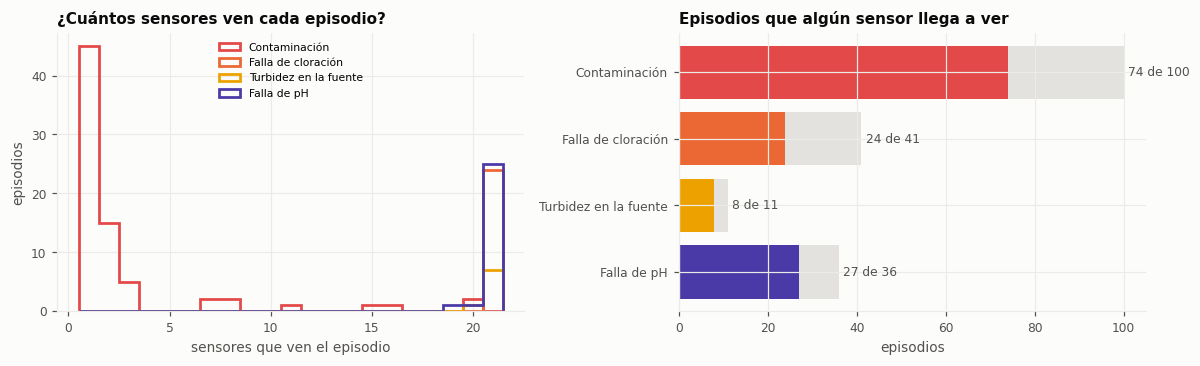

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for k, tipo in enumerate(TIPOS):
    d = red[(red.tipo == tipo) & red.visible]
    axes[0].hist(d["sensores que lo ven"], bins=np.arange(0.5, 22.5, 1), histtype="step", lw=1.8,
                 color=COLOR[tipo], label=NOMBRE[tipo])
axes[0].set_xlabel("sensores que ven el episodio"); axes[0].set_ylabel("episodios")
axes[0].set_title("¿Cuántos sensores ven cada episodio?", fontsize=10)
axes[0].legend(fontsize=7, loc="upper center")

vis = red.groupby("tipo")["visible"].agg(["sum", "size"]).loc[TIPOS]
axes[1].barh([NOMBRE[x] for x in TIPOS], vis["size"], color="#e3e2de", label="no visible")
axes[1].barh([NOMBRE[x] for x in TIPOS], vis["sum"], color=[COLOR[x] for x in TIPOS], label="visible")
for i, (s_, n_) in enumerate(zip(vis["sum"], vis["size"])):
    axes[1].text(n_ + 1, i, f"{s_} de {n_}", va="center", fontsize=8, color="#52514e")
axes[1].invert_yaxis(); axes[1].set_xlabel("episodios")
axes[1].set_title("Episodios que algún sensor llega a ver", fontsize=10)
fig.tight_layout()
guardar(fig, "05_alcance_eventos"); plt.show()

## 2. Desbalance de clases

Para entrenar un detector importa qué fracción de los datos corresponde a cada clase. Se cuenta por
**lectura de sensor** (cada sensor en cada instante de 15 min).

In [5]:
v = E.values.ravel()
balance = pd.Series(v).map(carga.TIPOS_EVENTO).value_counts(normalize=True).mul(100) \
            .reindex(["normal"] + TIPOS).rename(index=NOMBRE).to_frame("% de las lecturas")
balance["lecturas"] = pd.Series(v).map(carga.TIPOS_EVENTO).value_counts().reindex(["normal"] + TIPOS).values
balance

,% de las lecturas,lecturas
Normal,94.00,1383268
Contaminación,0.72,10609
Falla de cloración,1.79,26363
Turbidez en la fuente,0.91,13356
Falla de pH,2.58,38021


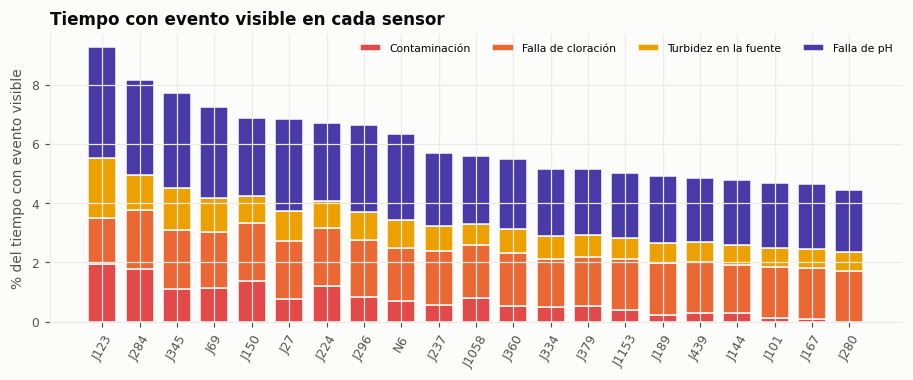

In [6]:
por_sensor = pd.DataFrame({tipo: (E == codigo).mean() * 100 for codigo, tipo in
                           zip([1, 2, 3, 4], TIPOS)})
por_sensor = por_sensor.loc[por_sensor.sum(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(10, 3.4))
abajo = np.zeros(len(por_sensor))
for tipo in TIPOS:
    ax.bar(por_sensor.index, por_sensor[tipo], bottom=abajo, color=COLOR[tipo], label=NOMBRE[tipo],
           width=0.75, edgecolor="#fcfcfb", linewidth=1)
    abajo += por_sensor[tipo].values
ax.set_ylabel("% del tiempo con evento visible")
ax.set_title("Tiempo con evento visible en cada sensor")
ax.tick_params(axis="x", rotation=60)
ax.legend(ncol=4, fontsize=7, loc="upper right")
guardar(fig, "05_eventos_por_sensor"); plt.show()

## 3. Un ejemplo de cada tipo

El episodio visible más largo de cada tipo, con cloro, turbidez y pH en los sensores que lo ven
(hasta cinco). La franja sombreada marca el episodio en la red.

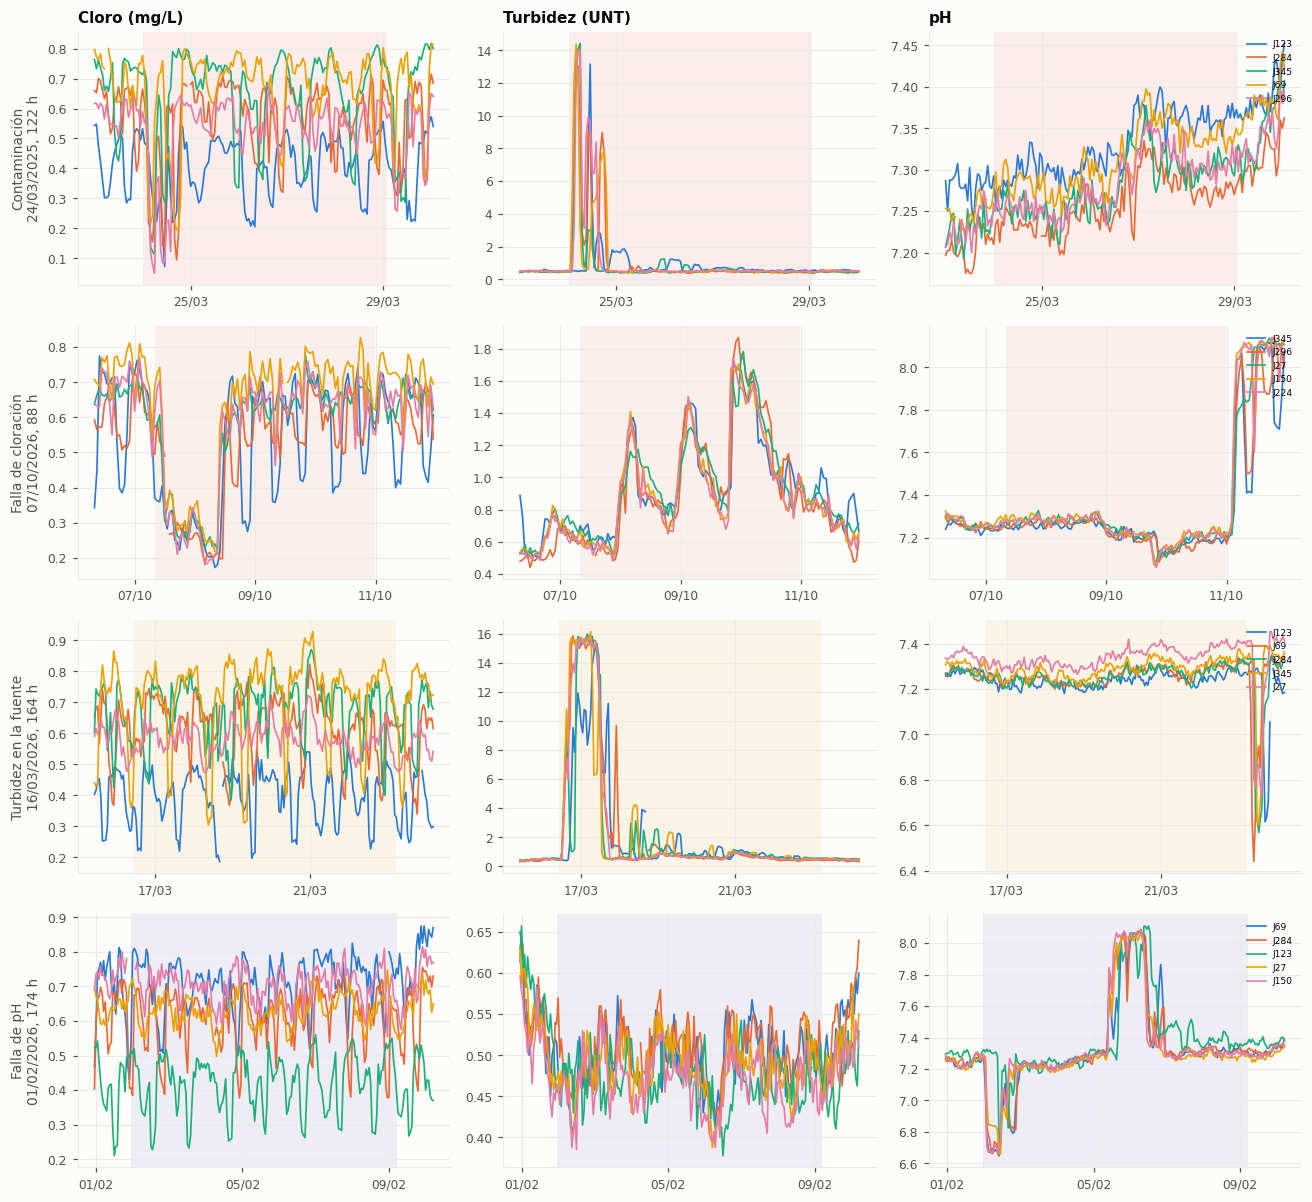

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(12, 11))
for fila, tipo in enumerate(TIPOS):
    ep = red[(red.tipo == tipo) & red.visible].sort_values("horas").iloc[-1]
    ventana = E.loc[ep.inicio: ep.fin + pd.Timedelta(hours=24)]
    ven = list(ventana.columns[(ventana == ep.codigo).any()])
    ven = sorted(ven, key=lambda n: -(ventana[n] == ep.codigo).sum())[:5]
    tramo = slice(ep.inicio - pd.Timedelta(hours=24), ep.fin + pd.Timedelta(hours=24))
    for col, p in enumerate(["CL2", "TURB", "PH"]):
        ax = axes[fila, col]
        ax.axvspan(ep.inicio, ep.fin, color=COLOR[tipo], alpha=0.08, lw=0)
        for k, n in enumerate(ven):
            ax.plot(t.loc[tramo, f"{p}_{n}"].resample("1h").mean(), color=COLORES[k], lw=1.1, label=n)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=4))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
        if fila == 0:
            ax.set_title({"CL2": "Cloro (mg/L)", "TURB": "Turbidez (UNT)", "PH": "pH"}[p], fontsize=10)
        if col == 0:
            ax.set_ylabel(f"{NOMBRE[tipo]}\n{ep.inicio:%d/%m/%Y}, {ep.horas:.0f} h", fontsize=9)
    axes[fila, 2].legend(fontsize=6, loc="upper right")
fig.tight_layout()
guardar(fig, "05_ejemplos_eventos"); plt.show()

## 4. Firma de cada tipo de evento

Para comparar sensores con niveles muy distintos (el cloro normal de J144 es 0,2 mg/L y el de J439,
0,87), se usa la **desviación respecto a lo típico**: la lectura horaria menos la mediana de ese
sensor a esa hora del día, calculada solo con la operación normal del periodo de entrenamiento.

In [8]:
PAR = ["CL2", "TURB", "PH"]
h = t[[f"{p}_{n}" for n in S for p in PAR]].resample("1h").mean()
eh = E.resample("1h").max()
entrenamiento = h.index < pd.Timestamp("2026-05-01")

# valor típico de cada sensor y parámetro por hora del día (operación normal, entrenamiento)
tipico = {}
for n in S:
    normal_entr = entrenamiento & (eh[n] == 0).values
    for p in PAR:
        x = h[f"{p}_{n}"][normal_entr]
        tipico[p, n] = x.groupby(x.index.hour).median().reindex(h.index.hour).values

def desviaciones(tabla_horaria, n):
    return {f"Δ{p}": (tabla_horaria[f"{p}_{n}"] - tipico[p, n]).values for p in PAR}

desv = pd.concat([pd.DataFrame({"sensor": n, "evento": eh[n].map(carga.TIPOS_EVENTO).values,
                                **desviaciones(h, n)}, index=h.index) for n in S])

desv.groupby("evento")[["ΔCL2", "ΔTURB", "ΔPH"]].median().loc[["normal"] + TIPOS].rename(index=NOMBRE).round(3)

,ΔCL2,ΔTURB,ΔPH
evento,,,
Normal,0.00,0.02,-8.00e-03
Contaminación,-0.31,3.06,3.00e-03
Falla de cloración,-0.45,0.05,-5.00e-03
Turbidez en la fuente,0.00,6.97,-2.00e-02
Falla de pH,-0.01,0.04,-2.10e-01


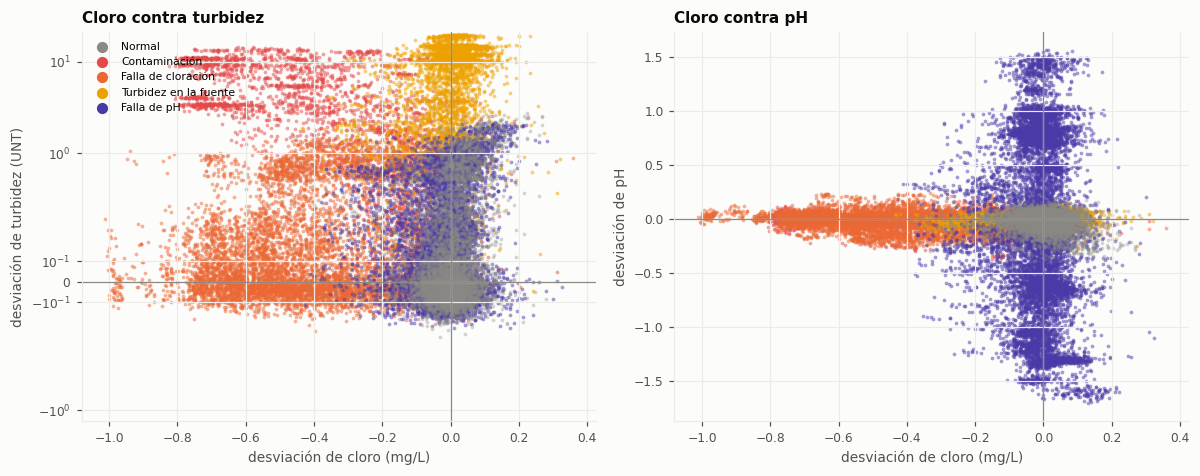

In [9]:
muestra = pd.concat([desv[desv.evento == "normal"].sample(6000, random_state=1),
                     desv[desv.evento != "normal"]]).dropna(subset=["ΔCL2", "ΔTURB"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (y, ylab) in zip(axes, [("ΔTURB", "desviación de turbidez (UNT)"), ("ΔPH", "desviación de pH")]):
    for tipo in TIPOS + ["normal"]:          # lo normal se dibuja encima, para que se vea
        d = muestra[muestra.evento == tipo]
        ax.scatter(d["ΔCL2"], d[y], s=6, alpha=0.35 if tipo == "normal" else 0.5, color=COLOR[tipo],
                   label=NOMBRE[tipo], linewidths=0)
    ax.axhline(0, color=GRIS, lw=0.8); ax.axvline(0, color=GRIS, lw=0.8)
    ax.set_xlabel("desviación de cloro (mg/L)"); ax.set_ylabel(ylab)
    if y == "ΔTURB":
        ax.set_yscale("symlog", linthresh=0.5)
axes[0].set_title("Cloro contra turbidez", fontsize=10)
axes[1].set_title("Cloro contra pH", fontsize=10)
h_, l_ = axes[0].get_legend_handles_labels()
orden_leg = [l_.index(NOMBRE[x]) for x in ["normal"] + TIPOS]
leg = axes[0].legend([h_[i] for i in orden_leg], [l_[i] for i in orden_leg], fontsize=7, markerscale=3, loc="upper left")
for l in leg.legend_handles:
    l.set_alpha(1)
fig.tight_layout()
guardar(fig, "05_firma_eventos"); plt.show()

## 5. ¿Evento o falla del sensor?

Una falla del sensor también puede bajar el cloro o subir la turbidez de un sensor. Para un
operador, confundir una falla del instrumento con una contaminación (o al revés) es costoso. Dos
pistas los distinguen:

- **cuántos sensores cambian a la vez**: una falla afecta a un solo sensor; un evento de la fuente,
  a muchos;
- **cuántos parámetros cambian a la vez**: una falla afecta a un solo parámetro; un evento suele
  mover varios.

Se cuenta, para cada hora con evento visible o con falla de sensor, cuántos sensores están
afectados y cuántos parámetros del sensor se desvían más que la tolerancia (cloro 0,1 mg/L,
turbidez 0,5 UNT, pH 0,2).

In [10]:
TOL = {"ΔCL2": 0.1, "ΔTURB": 0.5, "ΔPH": 0.2}
desv["parámetros desviados"] = sum((desv[c].abs() > tol).astype(int) for c, tol in TOL.items())

# horas con falla de sensor: se usan las lecturas crudas (antes de la limpieza), que sí traen la falla
crudo_h = crudo[[f"{p}_{n}" for n in S for p in PAR]].resample("1h").mean()
afectados_evento = (eh > 0).sum(axis=1).values

filas = []
for n in S:
    d = desv[desv.sensor == n]
    for tipo in TIPOS:
        m = (d.evento == tipo).values
        filas.append(pd.DataFrame({"clase": NOMBRE[tipo], "sensores a la vez": afectados_evento[m],
                                   "parámetros desviados": d["parámetros desviados"].values[m]}))
    con_falla = crudo[[f"falla_{p}_{n}" for p in PAR]].isin([1, 2, 3, 4]).any(axis=1).resample("1h").max().values
    m = con_falla & (eh[n] == 0).values
    dc = desviaciones(crudo_h, n)
    desviados = sum((np.abs(dc[f"Δ{p}"]) > TOL[f"Δ{p}"]).astype(int) for p in PAR)
    filas.append(pd.DataFrame({"clase": "Falla del sensor", "sensores a la vez": 1,
                               "parámetros desviados": desviados[m]}))
comp = pd.concat(filas)

tabla = comp.groupby("clase").agg(
    horas=("clase", "size"),
    sensores_con_evento_en_esa_hora_mediana=("sensores a la vez", "median"),
    pct_horas_con_2_o_más_parámetros=("parámetros desviados", lambda x: 100 * (x >= 2).mean()),
    pct_horas_sin_desviación=("parámetros desviados", lambda x: 100 * (x == 0).mean()),
).loc[[NOMBRE[x] for x in TIPOS] + ["Falla del sensor"]]
tabla

,horas,sensores_con_evento_en_esa_hora_mediana,pct_horas_con_2_o_más_parámetros,pct_horas_sin_desviación
clase,,,,
Contaminación,2971,3.0,73.48,7.27
Falla de cloración,7113,18.0,14.79,5.03
Turbidez en la fuente,3654,17.0,18.99,5.39
Falla de pH,10295,18.0,24.11,7.86
Falla del sensor,1358,1.0,8.76,41.24


## 6. Conclusiones e implicaciones para el modelo

**Lo que dicen los datos**

1. **En los dos años hay 188 eventos en la red, y algún sensor ve 133 (71 %).**
   - Contaminación: 100 episodios, 74 visibles.
   - Falla de cloración: 41 episodios, 24 visibles.
   - Turbidez en la fuente: 11 episodios, 8 visibles.
   - Falla de pH: 36 episodios, 27 visibles.

   Los que nadie ve son eventos que no llegan a ningún sensor, o que cambian las lecturas menos que
   lo medible.
2. **Las contaminaciones son locales; los eventos de la fuente, de toda la red.** La mayoría de las
   contaminaciones visibles las ve **un solo sensor**, porque entran en un punto y solo afectan
   el agua que pasa por ahí. Las fallas de cloración, de pH y la turbidez en la fuente las ven los
   21 sensores, empezando por J280 en la primera hora.
3. **Una de cada cuatro contaminaciones no la ve ningún sensor (26 %).** Ningún modelo puede
   detectar lo que los sensores no miden: con esta red de 21 sensores, el máximo alcanzable es
   cerca del 74 % de las contaminaciones.
4. **Los eventos son raros en los datos.** El 94 % de las lecturas son de operación normal; la
   contaminación es apenas el 0,7 %. Además, la **validación casi no tiene eventos de la fuente**:
   ningún episodio visible de turbidez en la fuente y solo uno de falla de pH.
5. **Cada tipo tiene una firma clara respecto a lo típico de su sensor:**

   | Tipo | Cloro | Turbidez | pH |
   |---|---|---|---|
   | Contaminación | −0,32 mg/L | +3,1 UNT | sin cambio |
   | Falla de cloración | −0,45 mg/L | sin cambio | sin cambio |
   | Turbidez en la fuente | sin cambio | +7,0 UNT | sin cambio |
   | Falla de pH | sin cambio | sin cambio | hasta ±1,5 |

   En la figura de cloro contra turbidez los cuatro tipos ocupan zonas casi separadas. La
   confusión está en las primeras y últimas horas de cada evento, cuando el cambio todavía es
   pequeño: entre el 5 y el 8 % de las horas con evento no se aparta de lo típico.
6. **Un evento y una falla del sensor se distinguen por cuántas cosas cambian a la vez:**
   - Una **falla del sensor** afecta a un solo sensor y un solo parámetro. Solo el 9 % de sus horas
     mueve dos parámetros, y el 41 % ni siquiera se aparta de lo típico (por ejemplo, un sensor
     pegado en un valor normal).
   - Los **eventos de la fuente** aparecen en unos 18 sensores a la vez.
   - Las **contaminaciones** mueven dos o más parámetros en el 73 % de sus horas, sobre todo cloro y
     turbidez juntos.

**Qué implica para el modelo**

- **Etiquetas:** entrenar con `evento_<nodo>` (lo visible en cada sensor), no con `evento_red`.
  Pedirle al modelo que detecte lo que ningún sensor ve solo le enseña a adivinar.
- **Evaluar la detección contra los eventos visibles y por episodio**, no por lectura. Reportar
  aparte el límite que pone la red: aunque el modelo sea perfecto, el 26 % de las contaminaciones
  no se ve. Si en la práctica hay margen, eso es un argumento para agregar sensores.
- **Variables que mezclen parámetros y sensores:**
  - desviación de cada parámetro respecto a lo típico del sensor a esa hora;
  - cuántos parámetros se desvían a la vez;
  - cuántos sensores se desvían a la vez.

  Con eso se separan contaminación, eventos de la fuente y fallas del sensor.
- **Desbalance:** usar pesos por clase o un enfoque de anomalías (aprender solo lo normal y marcar
  lo que se aparta). Medir con falsas alarmas por semana y eventos detectados, no con exactitud
  general: un modelo que siempre dice "normal" ya acierta el 94 %.
- **La validación no alcanza para calibrar todo.** Con tan pocos eventos de la fuente en mayo–agosto,
  conviene usar validación cruzada por bloques de tiempo dentro del entrenamiento (por ejemplo,
  meses consecutivos) para elegir umbrales, y dejar la prueba solo para el resultado final.